# GPU-Accelerated Machine Learning with NVIDIA RAPIDS cuML
## High-Performance Random Forest Classification & ROC/AUC Evaluation
**Author:** Eugene Phang  
**Domain:** GPU Computing, NVIDIA RAPIDS cuML, High-Throughput Model Training  

---

### Overview
When scaling tabular machine learning pipelines to millions of rows or executing intensive cross-validation routines, CPU-based Scikit-Learn training can become a major computational bottleneck. This notebook illustrates how to accelerate ensemble training using **NVIDIA RAPIDS cuML** on Google Colab GPU runtimes.

### Highlights
* Seamless migration from Scikit-Learn to GPU-accelerated .
* Stratified K-Fold cross-validation with class imbalance handling.
* Comprehensive diagnostic evaluation including Confusion Matrices, ROC Curves, and Area Under the Curve (AUC) metrics.


In [ ]:
# Install RAPIDS cuML
# This command is specific for Colab and installs the necessary packages for GPU acceleration.
#!pip install cuml-cu12 --extra-index-url https://pypi.nvidia.com

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
import os
#os.chdir('c:/py/data')
os.chdir('/content/drive/MyDrive/repo/Lexi') #<-- your local
print(os.getcwd())

/content/drive/MyDrive/repo/Lexi


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

In [ ]:
historical = pd.read_csv('race_predictions.csv', header=0, encoding='utf-8', sep=',')
formdata = pd.read_csv('form data.csv', header=0, encoding='utf-8', sep=',')

historical.head()
print(historical.columns)
print(f"Total number of rows in historical: {historical.shape[0]}")
#formdata.head()

/tmp/ipython-input-3523356083.py:1: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  historical = pd.read_csv('race_predictions.csv', header=0, encoding='utf-8', sep=',')


Index(['Key', 'date', 'time', 'track', 'race_number', 'Field Size', 'Places',
       'horse_number', 'horse_name', 'lexi_tip_line', 'Rank Change',
       'morning_odds', 'race_time_odds', 'sp_odds', 'Place Odds', 'result',
       'won_flag', 'placed_flag', 'outsider_flag', 'outsider_win_flag',
       'SCRATCHED', 'Strategy Qualified', 'Strategy Stake T1',
       'Strategy Stake T2', 'Strategy Stake T3', 'Strategy Stake T4',
       'Strategy Total Stake', 'Strategy Target Return', 'Strategy Return',
       'Strategy Profit', 'Strategy ROI', 'Strategy Comment'],
      dtype='object')
Total number of rows in historical: 109930


In [ ]:
rows = historical.shape[0]

features = ['track', 'race_number', 'Field Size', 'Places', 'horse_name', 'Rank Change', 'morning_odds', 'race_time_odds', 'sp_odds', 'Place Odds', 'outsider_flag']
targets = ['won_flag']

feature_inds = [historical.columns.get_loc(col) for col in features]
target_inds = [historical.columns.get_loc(col) for col in targets]

X = historical.iloc[0:rows, feature_inds].values
y = historical.iloc[0:rows, target_inds].values

# Add X_Geelong variable
track_column_index_in_X = features.index('track')
X_Geelong = X[X[:, track_column_index_in_X] == 'Geelong']
y_Geelong = y[X[:, track_column_index_in_X] == 'Geelong']

In [ ]:
import sys
import numpy as np

# Set print options to display the full array without truncation
np.set_printoptions(threshold=sys.maxsize, linewidth=sys.maxsize)

# Print X again with the new print options
#print(X)

In [ ]:
from sklearn.model_selection import train_test_split

# Split the data into training and testing sets (75% train, 25% test)
#X_train, X_test, y_train, y_test = train_test_split(X_Geelong, y_Geelong, test_size=0.25, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (82447, 11)
X_test shape: (27483, 11)
y_train shape: (82447, 1)
y_test shape: (27483, 1)


Geelong:
X_train shape: (984, 11)
X_test shape: (328, 11)
y_train shape: (984, 1)
y_test shape: (328, 1)

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score, matthews_corrcoef
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer # Corrected import path for SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Identify categorical features by their indices in the X array
# Based on the 'features' list: ['track', 'race_number', 'Field Size', 'Places', 'horse_name', 'Rank Change', 'morning_odds', 'race_time_odds', 'sp_odds', 'Place Odds', 'outsider_flag']
# The string columns are at indices 0 (track), 4 (horse_name), and 5 (Rank Change)
categorical_features_indices = [0, 4, 5]

# Identify numerical features (all others)
all_feature_indices = list(range(X_train.shape[1]))
numerical_features_indices = [i for i in all_feature_indices if i not in categorical_features_indices]

# Create a ColumnTransformer to apply different preprocessing steps to different columns
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features_indices),
        ('num', SimpleImputer(strategy='mean'), numerical_features_indices) # Impute missing numerical values
    ],
    remainder='passthrough' # Keep any other columns as they are (though there shouldn't be any if all are covered)
)

# Apply the preprocessing to X_train and X_test
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# Initialize the Random Forest Classifier
# Setting n_estimators to 10 and min_samples_split to 5 as requested
rf_classifier = RandomForestClassifier(n_estimators=10, min_samples_split=5, random_state=42)

# Train the model using the processed training data
rf_classifier.fit(X_train_processed, y_train.ravel()) # .ravel() is used to convert y_train from (n, 1) to (n,)

# Make predictions on the processed test data
y_pred = rf_classifier.predict(X_test_processed)
y_pred_proba = rf_classifier.predict_proba(X_test_processed)[:, 1] # Get probabilities for the positive class

# Evaluate the model
print("Random Forest Classifier Performance:")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

# Calculate and print AUC and MCC
print("AUC: ", roc_auc_score(y_test, y_pred_proba))
print("MCC: ", matthews_corrcoef(y_test, y_pred))

Random Forest Classifier Performance:
Accuracy: 0.948331695957501
Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.99      0.97     22807
           1       0.93      0.75      0.83      4676

    accuracy                           0.95     27483
   macro avg       0.94      0.87      0.90     27483
weighted avg       0.95      0.95      0.95     27483

AUC:  0.9781110426642159
MCC:  0.808217909882405


In [ ]:
from sklearn.model_selection import StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, matthews_corrcoef
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
import numpy as np

# Identify categorical features by their indices in the X array
categorical_features_indices = [0, 4, 5]
all_feature_indices = list(range(X_train.shape[1]))
numerical_features_indices = [i for i in all_feature_indices if i not in categorical_features_indices]

# Initialize StratifiedKFold
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# Lists to store metrics for each fold
accuracies = []
precisions = []
recalls = []
f1_scores = []
aucs = []
mccs = []

print("Starting 10-Fold Stratified Cross-Validation...\n")

for fold, (train_index, val_index) in enumerate(skf.split(X_train, y_train), 1):
    print(f"--- Fold {fold}/10 ---")
    X_fold_train, X_fold_val = X_train[train_index], X_train[val_index]
    y_fold_train, y_fold_val = y_train[train_index], y_train[val_index]

    # Create a new preprocessor for each fold to avoid data leakage
    # and fit it only on the fold's training data
    fold_preprocessor = ColumnTransformer(
        transformers=[
            ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features_indices),
            ('num', SimpleImputer(strategy='mean'), numerical_features_indices)
        ],
        remainder='passthrough'
    )

    X_fold_train_processed = fold_preprocessor.fit_transform(X_fold_train)
    X_fold_val_processed = fold_preprocessor.transform(X_fold_val)

    # Initialize a new Random Forest Classifier for each fold
    rf_classifier_fold = RandomForestClassifier(n_estimators=10, min_samples_split=5, random_state=42)

    # Train the model
    rf_classifier_fold.fit(X_fold_train_processed, y_fold_train.ravel())

    # Make predictions
    y_fold_pred = rf_classifier_fold.predict(X_fold_val_processed)
    y_fold_pred_proba = rf_classifier_fold.predict_proba(X_fold_val_processed)[:, 1]

    # Calculate and store metrics
    accuracies.append(accuracy_score(y_fold_val, y_fold_pred))
    precisions.append(precision_score(y_fold_val, y_fold_pred, zero_division=0))
    recalls.append(recall_score(y_fold_val, y_fold_pred, zero_division=0))
    f1_scores.append(f1_score(y_fold_val, y_fold_pred, zero_division=0))
    aucs.append(roc_auc_score(y_fold_val, y_fold_pred_proba))
    mccs.append(matthews_corrcoef(y_fold_val, y_fold_pred))

    print(f"  Accuracy: {accuracies[-1]:.4f}")
    print(f"  AUC: {aucs[-1]:.4f}")
    print(f"  MCC: {mccs[-1]:.4f}")
    print("-" * 20)


print("\n--- Overall Cross-Validation Results (Mean +/- Std Dev) ---")
print(f"Accuracy: {np.mean(accuracies):.4f} (+/- {np.std(accuracies):.4f})")
print(f"Precision: {np.mean(precisions):.4f} (+/- {np.std(precisions):.4f})")
print(f"Recall: {np.mean(recalls):.4f} (+/- {np.std(recalls):.4f})")
print(f"F1-Score: {np.mean(f1_scores):.4f} (+/- {np.std(f1_scores):.4f})")
print(f"AUC: {np.mean(aucs):.4f} (+/- {np.std(aucs):.4f})")
print(f"MCC: {np.mean(mccs):.4f} (+/- {np.std(mccs):.4f})")

Starting 10-Fold Stratified Cross-Validation...

--- Fold 1/10 ---
  Accuracy: 0.9389
  AUC: 0.9693
  MCC: 0.7773
--------------------
--- Fold 2/10 ---
  Accuracy: 0.9406
  AUC: 0.9701
  MCC: 0.7838
--------------------
--- Fold 3/10 ---
  Accuracy: 0.9383
  AUC: 0.9660
  MCC: 0.7748
--------------------
--- Fold 4/10 ---
  Accuracy: 0.9420
  AUC: 0.9741
  MCC: 0.7894
--------------------
--- Fold 5/10 ---
  Accuracy: 0.9401
  AUC: 0.9708
  MCC: 0.7819
--------------------
--- Fold 6/10 ---
  Accuracy: 0.9421
  AUC: 0.9724
  MCC: 0.7899
--------------------
--- Fold 7/10 ---
  Accuracy: 0.9398
  AUC: 0.9715
  MCC: 0.7810
--------------------
--- Fold 8/10 ---
  Accuracy: 0.9426
  AUC: 0.9737
  MCC: 0.7916
--------------------
--- Fold 9/10 ---
  Accuracy: 0.9436
  AUC: 0.9718
  MCC: 0.7956
--------------------
--- Fold 10/10 ---
  Accuracy: 0.9383
  AUC: 0.9685
  MCC: 0.7749
--------------------

--- Overall Cross-Validation Results (Mean +/- Std Dev) ---
Accuracy: 0.9406 (+/- 0.0018)

The ROC curve shows the performance of a binary classifier with different decision thresholds. It plots the True Positive rate (TPR) against the False Positive rate (FPR).
The ROC AUC score is the area under the ROC curve. It sums up how well a model can produce relative scores to discriminate between positive or negative instances across all classification thresholds.
The ROC AUC score ranges from 0 to 1, where 0.5 indicates random guessing, and 1 indicates perfect performance.

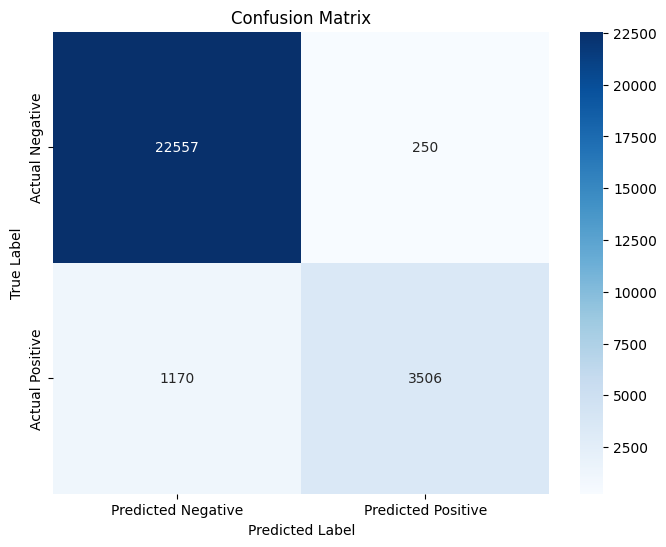

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Negative', 'Predicted Positive'],
            yticklabels=['Actual Negative', 'Actual Positive'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

### Switching to GPU Runtime and Using cuML

To utilize a GPU, you must first change your Colab notebook's runtime type:

1.  Go to `Runtime` in the Colab menu.
2.  Select `Change runtime type`.
3.  In the dialog, choose `GPU` as the `Hardware accelerator`.
4.  Click `Save`.

After switching to a GPU runtime, you can install `cuML`, a GPU-accelerated machine learning library from the RAPIDS suite, which offers scikit-learn-like APIs for many algorithms, including Random Forest.

### Adapting the Random Forest Model to use cuML

Once `cuML` is installed and you are on a GPU runtime, you can modify your model training cell to use `cuml.ensemble.RandomForestClassifier`. The API is designed to be very similar to scikit-learn's equivalent.

**Note**: For optimal performance with `cuML`, it's often beneficial to convert your data (X_train_processed, y_train) to GPU-compatible formats like `cupy` arrays or `cudf` DataFrames, especially for larger datasets. However, `cuml` can often handle NumPy arrays directly, moving them to GPU internally. For this example, we'll primarily focus on replacing the scikit-learn import with the `cuml` import.

In [ ]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Load the new input data
#input_data = pd.read_csv('input-rr.csv', header=0, encoding='utf-8', sep=',')
input_data = pd.read_csv('filtered_results_data.csv', header=0, encoding='utf-8', sep=',')
# Ensure the input data has the same features in the same order
# as used for training (defined in the 'features' list earlier)
X_new = input_data[features].values

# Preprocess the new input features using the already fitted preprocessor
X_new_processed = preprocessor.transform(X_new)

# Make predictions using the trained Random Forest model
y_new_pred = rf_classifier.predict(X_new_processed)
y_new_pred_proba = rf_classifier.predict_proba(X_new_processed)[:, 1] # Probability of winning

print("Predictions for new input data (won_flag):")
print(y_new_pred)
print("\nPrediction probabilities for new input data (winning chance):")
print(y_new_pred_proba)

# Add predictions to the input_data DataFrame for easy filtering
input_data['predicted_won_flag'] = y_new_pred
input_data['prediction_probability'] = y_new_pred_proba

# Filter for predictions where won_flag is 1
winning_predictions = input_data[input_data['predicted_won_flag'] == 1]

# Check if the original 'won_flag' column exists in the input data
include_actual_won_flag = 'won_flag' in input_data.columns

# Sort winning predictions by probability in descending order
winning_predictions = winning_predictions.sort_values(by='prediction_probability', ascending=False)

# Print the desired columns for winning predictions in a formatted way
print("\n--- Details for Predicted Winning Horses ---")
if not winning_predictions.empty:
    # Define columns and their display widths
    cols = ['Date', 'Track', 'Race #', 'Horse Name', 'Probability']
    widths = [12, 18, 8, 28, 12]

    if include_actual_won_flag:
        cols.append('Actual Won')
        widths.append(12)

    header_format = " ".join([f"{{:<{w}}}" for w in widths])
    print(header_format.format(*cols))
    print("-" * sum(widths + [len(cols) - 1])) # Separator line

    for index, row in winning_predictions.iterrows():
        output_values = [
            row['date'],
            row['track'],
            str(row['race_number']),
            row['horse_name'],
            f"{row['prediction_probability']:.2f}"
        ]
        if include_actual_won_flag:
            output_values.append(str(row['won_flag']))
        print(header_format.format(*output_values))
else:
    print("No predicted winning horses found.")

# Provide a summary of accuracy if 'won_flag' (actual) is available and has non-NaN values
if include_actual_won_flag:
    # Filter out rows where 'won_flag' is NaN before calculating metrics
    valid_predictions_for_metrics = input_data.dropna(subset=['won_flag']).copy()

    if not valid_predictions_for_metrics.empty:
        print("\n--- Prediction Accuracy Summary ---")
        y_true_all = valid_predictions_for_metrics['won_flag'].values
        y_pred_all = valid_predictions_for_metrics['predicted_won_flag'].values

        overall_accuracy = accuracy_score(y_true_all, y_pred_all)
        overall_precision = precision_score(y_true_all, y_pred_all, zero_division=0) # Handle cases with no positive predictions
        overall_recall = recall_score(y_true_all, y_pred_all, zero_division=0)
        overall_f1 = f1_score(y_true_all, y_pred_all, zero_division=0)

        print(f"Total Number of Valid Predictions for Metrics: {len(y_true_all)}")
        print(f"Number of Actual Wins: {y_true_all.sum()}")
        print(f"Number of Predicted Wins: {y_pred_all.sum()}")
        print(f"Overall Accuracy: {overall_accuracy:.4f}")
        print(f"Overall Precision: {overall_precision:.4f}")
        print(f"Overall Recall: {overall_recall:.4f}")
        print(f"Overall F1-Score: {overall_f1:.4f}")
    else:
        print("\n--- Prediction Accuracy Summary ---")
        print("No valid 'won_flag' values found in the input data to calculate accuracy metrics.")


Predictions for new input data (won_flag):
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]

Prediction probabilities for new input data (winning chance):
[0.         0.         0.         0.         0.         0.         0.         0.         0.         0.06666667 0.06666667 0.06666667 0.06666667 0.06666667 0.06666667 0.06666667 0.06666667 0.06666667 0.06666667 0.06666667 0.06666667 0.06666667 0.06666667 0.06666667 0.06666667 0.06666667 0.06666667 0.06666667 0.06666667 0.06666667 0.06666667 0.06666667 0.06666667 0.06666667 0.06666667 0.06666667 0.06666667 0.16666667 0.06666667 0.06666667 0.06666667 0.06666667 0.06666667 0.16666667 0.06666667 0.06666667 0.06666667 0.06666667 0.06666667 0.06666667 0.06666667 0.06666667 0.06666667 0.06666667 0.06666667 0.06666667 0.06666667 0.06666667 0.06666667 0.06666667 0.06666667 0.06666667 0.06666667 0.06666667 0.06666667 0.06666667 0.06666667 0.06666667 0

In [ ]:
import pandas as pd
import numpy as np
import re
from pathlib import Path

INPUTS = [
    "/mnt/data/2026-02-11-gosford-form.csv",
    "/mnt/data/2026-02-11-belmont-park-form.csv",
    "/mnt/data/2026-02-11-gawler-form.csv",
    "/mnt/data/2026-02-11-sale-form.csv",
    "/mnt/data/2026-02-11-doomben-form.csv",
]

def zscore(s: pd.Series) -> pd.Series:
    s = s.astype(float)
    sd = s.std(ddof=0)
    if sd == 0 or np.isnan(sd):
        return pd.Series(0.0, index=s.index)
    return (s - s.mean()) / sd

def minmax_0_100(s: pd.Series) -> pd.Series:
    s = s.astype(float)
    mn, mx = s.min(), s.max()
    if mx == mn or np.isnan(mx) or np.isnan(mn):
        return pd.Series(50.0, index=s.index)
    return (s - mn) / (mx - mn) * 100.0

def find_col(df, patterns):
    for p in patterns:
        cols = [c for c in df.columns if re.search(p, c, re.IGNORECASE)]
        if cols:
            return cols[0]
    return None

def run_start_count(df):
    # Prefer an explicit career starts column if it exists, otherwise count non-null historical form positions.
    c = find_col(df, [r"\bCareerStarts\b", r"\bStarts\b", r"\bRuns\b"])
    if c:
        return pd.to_numeric(df[c], errors="coerce")
    pos_cols = [c for c in df.columns if re.match(r"Forms\[\d+\]\.Position$", c)]
    if not pos_cols:
        return pd.Series(np.nan, index=df.index)
    return df[pos_cols].notna().sum(axis=1)

def recent_finish_percentile(df, i):
    # Converts position + starters into a 0..1 "finish strength" (1 = won, 0 = last-ish).
    pos_c = f"Forms[{i}].Position"
    st_c  = find_col(df, [rf"Forms\[{i}\]\.(Starters|Runners|FieldSize|NoRunners)\b"])
    if pos_c not in df.columns or not st_c:
        return pd.Series(np.nan, index=df.index)

    pos = pd.to_numeric(df[pos_c], errors="coerce")
    st  = pd.to_numeric(df[st_c], errors="coerce")
    denom = (st - 1).replace(0, np.nan)
    pct = 1 - ((pos - 1) / denom)
    return pct.clip(0, 1)

def recent_margin_factor(df, i):
    m_c = f"Forms[{i}].Margin"
    if m_c not in df.columns:
        return pd.Series(np.nan, index=df.index)
    m = pd.to_numeric(df[m_c], errors="coerce")
    # Smaller margin = better. Exponential decay; forgiving for small margins.
    return np.exp(-m.clip(lower=0) / 6.0)

def build_scores(df):
    # Keys
    race_id = find_col(df, [r"\bRaceId\b"])
    tab_no  = find_col(df, [r"\bTabNo\b"])
    name_c  = find_col(df, [r"\bRunnerName\b", r"\bHorseName\b", r"\bName\b"])

    if not race_id or not tab_no:
        raise ValueError("Missing RaceId or TabNo in file — can’t group/rank correctly.")

    # Scratched handling (best-effort)
    scratch_c = find_col(df, [r"Scratch", r"\bIsScratched\b"])
    scratched = pd.Series(False, index=df.index)
    if scratch_c:
        v = df[scratch_c]
        scratched = v.astype(str).str.upper().isin(["TRUE","1","YES","SCRATCHED"])

    # Market price (for Value/Chaos). If not present, Chaos still works off volatility.
    price_c = find_col(df, [r"\bPrice(?!.*Start)\b", r"\bSP\b", r"StartingPrice", r"PriceStarting"])
    price = pd.to_numeric(df[price_c], errors="coerce") if price_c else pd.Series(np.nan, index=df.index)

    # --- STRUCTURAL ---
    weights = np.array([1.0, 0.75, 0.55, 0.40, 0.25], dtype=float)
    finish = []
    marg   = []
    for i in range(5):
        finish.append(recent_finish_percentile(df, i))
        marg.append(recent_margin_factor(df, i))

    finish_mat = np.vstack([s.to_numpy() for s in finish])
    marg_mat   = np.vstack([s.to_numpy() for s in marg])

    # If margin missing, treat as neutral 1.0 for that row
    marg_mat = np.where(np.isnan(marg_mat), 1.0, marg_mat)
    # If finish missing, treat as NaN and exclude from weighted average
    w = weights[:, None] * (~np.isnan(finish_mat))
    wsum = np.sum(w, axis=0)
    struct_raw = np.nansum((finish_mat * marg_mat) * weights[:, None], axis=0) / np.where(wsum==0, np.nan, wsum)

    struct_raw = pd.Series(struct_raw, index=df.index)

    # --- CHAOS (orthogonal) ---
    # Volatility: std dev of finish percentile across last runs
    vol = pd.Series(np.nanstd(finish_mat, axis=0), index=df.index)

    # Spike/improvement: last run vs mean of runs 1..4
    last = finish[0]
    prev_mean = pd.Series(np.nanmean(finish_mat[1:,:], axis=0), index=df.index)
    spike = (last - prev_mean).fillna(0)

    # Inexperience: fewer runs => more chaos
    runs = run_start_count(df).fillna(0)
    inexp = 1.0 / (1.0 + runs.clip(lower=0))

    # Odds factor: bigger odds => more chaos (within-race)
    odds_factor = np.log1p(price.fillna(price.median(skipna=True) if price.notna().any() else 10.0))

    # Build chaos raw, then de-correlate from structural
    chaos_raw = 0.35 * zscore(vol.fillna(0)) + 0.20 * zscore(spike) + 0.20 * zscore(inexp) + 0.25 * zscore(odds_factor)

    # De-correlate: push Chaos away from simply “same as Structural”
    chaos_raw = chaos_raw - 0.60 * zscore(struct_raw.fillna(struct_raw.median(skipna=True)))

    # --- VALUE ---
    # “Fair” proxy from structural: higher structural => lower fair odds.
    # This is not a full probability model, but it’s enough to get a useful overlay ranking.
    fair_p = struct_raw.clip(0.01, 0.99)
    fair_odds = (1.0 / fair_p).replace([np.inf, -np.inf], np.nan)

    # Value = market odds / fair odds  ( >1 = overs )
    value_raw = (price / fair_odds) if price_c else pd.Series(np.nan, index=df.index)

    # --- CONFIDENCE ---
    # More usable runs => higher confidence. Also penalise if key signals missing.
    usable_runs = pd.Series(np.sum(~np.isnan(finish_mat), axis=0), index=df.index)
    confidence_raw = usable_runs / 5.0
    confidence_raw = confidence_raw.clip(0, 1)

    # Convert to 0..100 within-race for display + ranks
    out = df.copy()
    out["HorseNumber"] = out[tab_no]  # Tab number as requested

    # Exclude scratched from ranking/scaling (they keep NaNs)
    mask = ~scratched

    def within_race_scale(series):
        scaled = pd.Series(np.nan, index=series.index)
        for rid, idx in out[mask].groupby(race_id).groups.items():
            scaled.loc[idx] = minmax_0_100(series.loc[idx])
        return scaled

    out["BomberScore_Structural"] = within_race_scale(struct_raw)
    out["BomberScore_Chaos"]      = within_race_scale(chaos_raw)
    out["BomberScore_Value"]      = within_race_scale(value_raw.fillna(value_raw.median(skipna=True)))
    out["BomberScore_Confidence"] = within_race_scale(confidence_raw)

    def within_race_rank(score_col):
        r = pd.Series(np.nan, index=out.index)
        for rid, idx in out[mask].groupby(race_id).groups.items():
            r.loc[idx] = out.loc[idx, score_col].rank(ascending=False, method="min")
        return r

    out["BomberRank_Structural"]  = within_race_rank("BomberScore_Structural")
    out["BomberRank_Chaos"]       = within_race_rank("BomberScore_Chaos")
    out["BomberRank_Value"]       = within_race_rank("BomberScore_Value")
    out["BomberRank_Confidence"]  = within_race_rank("BomberScore_Confidence")

    return out

for p in INPUTS:
    df = pd.read_csv(p)
    scored = build_scores(df)
    out_path = str(Path(p).with_name(Path(p).stem.replace("-form","") + "-bomber-scores.csv"))
    scored.to_csv(out_path, index=False)
    print("Wrote:", out_path)


### 1. Authenticate to Google Cloud

Run the following cell to authenticate your Colab environment with Google Cloud. This will open a new window or tab where you'll need to select your Google account and grant the necessary permissions.

In [ ]:
from google.colab import auth
auth.authenticate_user()

### 2. Set your Google Cloud Project ID

Replace `'your-gcp-project-id'` with the actual ID of your Google Cloud Project. This tells Colab which project's resources to interact with.

In [ ]:
project_id = "your-gcp-project-id"  # Set to your GCP project ID
!gcloud config set project {project_id}


Updated property [core/project].


To take a quick anonymous survey, run:
  $ gcloud survey

Google Cloud Project set to: lexi-tips-ai-2026


### 3. Verify Connection (Optional)

You can optionally run a command to verify that you're connected to the correct project and can access resources, for example, listing your Cloud Storage buckets.

In [ ]:
# Example: List Google Cloud Storage buckets in your project
# This command requires the 'gsutil' tool, which is pre-installed in Colab
!gsutil ls

# If you have specific resources you want to check, replace '!gsutil ls' with the appropriate gcloud command, e.g., '!gcloud compute instances list'

You are attempting to perform an operation that requires a project id, with none configured. Please re-run gsutil config and make sure to follow the instructions for finding and entering your default project id.
